# Laboratory 8: Modeling Major Trends in Global Population Growth



## 1. Introduction

**Overview:**

Understanding global population dynamics is crucial for planning sustainable development, resource allocation, and addressing socioeconomic challenges. This laboratory explores the major trends in population growth around the world, focusing on factors such as fertility, mortality, migration, population momentum, aging populations, and urbanization. By modeling these factors, you will gain insights into how different regions contribute to global population changes and the implications for future development. The entirety of the laboratory is focused around the scientific paper called [Major Trends in Population Growth Around the World](https://pmc.ncbi.nlm.nih.gov/articles/PMC8393076/) and the extraction of meaningful observations and statistics from this work.

**Objectives:**

- Comprehend key factors influencing global population growth.
- Learn about population momentum and its impact on future trends.
- Implement a population projection model considering fertility, mortality, and migration.
- Analyze and visualize population growth trends across different regions.
- Discuss the implications of population dynamics on sustainable development.

## 2. Background

### Major Trends in Population Growth

The global population reached **7.8 billion** by mid-2020, increasing from **7 billion** in 2010. The average annual growth rate has been declining, from **2.3%** in the late 1960s to approximately **1.1%** in recent years. This slowdown is largely due to decreases in fertility rates, especially in high-income and upper-middle-income countries where fertility rates have fallen below the replacement level of **2.1 births per woman**.

**Population Momentum:**

Population momentum refers to the potential for population growth based on the existing age structure. Even with declining fertility rates, populations can continue to grow for several decades due to a large base of young individuals entering their reproductive years. Globally, population momentum is projected to contribute **1.3 billion** additional people between 2020 and 2050.


**Regional Variations:**

Sub-Saharan Africa is expected to experience the most significant population growth, contributing over half of the global population increase by 2050. In contrast, regions like Europe and Northern America are projected to see stagnant or declining populations.

**Aging Populations:**

As fertility rates decline and life expectancy increases, many countries are experiencing unprecedented population aging. By 2050, the global proportion of individuals aged 65 or older is expected to reach **15.9%**, increasing to **22.4%** by 2100.

**Migration and Urbanization:**

International migration has risen, with significant concentrations in countries like the United States, Germany, and Saudi Arabia. Urbanization trends show a continued shift of populations from rural to urban areas, with the global urban population projected to exceed **68%** by 2050.


## 3. Research and Data Extraction

### Selecting Key Parameters

To model population growth, we will focus on the following components:

- **Fertility Rate (TFR):** Total number of births per woman.
- **Mortality Rate:** Number of deaths per population.
- **Migration Rate:** Net migration (immigrants minus emigrants).
- **Population Momentum:** Based on the current age structure.

### Extracting Data from the Paper

From the paper **"Major Trends in Population Growth Around the World"** by Gu, Andreev, and Dupre, we extract the following key insights and data points:

1. **Global Population Growth:**
   - **Current Population (2020):** 7.8 billion
   - **Projected Population (2050):** 9.7 billion
   - **Projected Population (2100):** 10.9 billion
   - **Growth Rate (2020-2050):** 1.1% annual growth rate, decreasing from 2.3% in the late 1960s.

2. **Population Momentum:**
   - **Contribution to Growth (2020-2050):** 1.3 billion additional people (17% of the total increase).
   - **Explanation:** A large base of young population continues to grow even as fertility rates decline.

3. **Regional Growth Patterns:**
   - **Sub-Saharan Africa:**
     - **Projected Population (2100):** 3.8 billion (95% projection interval: 3.0 - 4.8 billion)
     - **Growth Rate:** Most rapid among regions, contributing more than half of the global population increase.
   - **Europe and Northern America:**
     - **Projected Population (2100):** Europe and Northern America combined to maintain or slightly decrease their population.
   - **Asia:**
     - **China:** Projected to decline to 1.40 billion by 2050, down from 1.43 billion in 2020.
     - **India:** Projected to overtake China as the most populous country by 2025-2030, reaching 1.64 billion by 2050 and then declining to 1.45 billion by 2100.

4. **Aging Populations:**
   - **Global Old-Age Proportion (2020):** 9.3%
   - **Projected Old-Age Proportion (2050):** 15.9%
   - **Projected Old-Age Proportion (2100):** 22.4%

5. **Migration Patterns**:

   - **Global Migrants (2020)**: 281 million
   - **Top Destination Countries**: United States, Germany, Saudi Arabia, Russian Federation, United Kingdom.
   - **Top Origin Countries**: India, Mexico, China, Russian Federation.
   - **Impact**: Significant in regions like Gulf States, contributing to rapid population growth.

6. **Urbanization**:

   - **Global Urban Population (2020)**: 56%
   - **Projected Urban Population (2050)**: 68%
   - **Regional Urbanization Rates**:
     - **Northern America**: 82.6% in 2020, projected to 89.0% by 2050.
     - **Sub-Saharan Africa**: 41.4% in 2020, projected to 58.1% by 2050.

### Example of Data Extraction and Parameter Selection

Let's consider Sub-Saharan Africa for our population projection model:

- Initial Population (2020): 1.1 billion
- Fertility Rate (TFR): 4.5 births per 1,000 population
- Mortality Rate: 8 deaths per 1,000 population
- Migration Rate: 2 net migrants per 1,000 population
- Projection Years: 80 years (2020-2100)

In [3]:
!pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4. Python Implementation

We will implement a simplified population projection model considering fertility, mortality, and migration rates. The model will project population growth over time for selected regions based on parameters extracted from the paper.

In [4]:
def population_projection(initial_population, fertility_rate, mortality_rate, migration_rate, years):
    """
    Projects population over a specified number of years.

    Parameters:
    - initial_population (int): Starting population.
    - fertility_rate (float): Number of births per 1,000 population per year.
    - mortality_rate (float): Number of deaths per 1,000 population per year.
    - migration_rate (float): Number of net migrants per 1,000 population per year.
    - years (int): Number of years to project.

    Returns:
    - pd.DataFrame: DataFrame containing population projection over time.
    """
    population = initial_population
    projection = {'Year': [0], 'Population': [population]}

    for year in range(1, years + 1):
        births = population * fertility_rate / 1000  # births per year
        deaths = population * mortality_rate / 1000  # deaths per year
        migrants = population * migration_rate / 1000  # net migrants per year

        # Update population
        population = population + births - deaths + migrants
        projection['Year'].append(year)
        projection['Population'].append(int(population))

    return pd.DataFrame(projection)


### Running the Projection for Selected Regions
We will project populations for three regions as examples:

- Sub-Saharan Africa
- Europe and Northern America
- Asia

In [5]:
# Define projection parameters for each region
regions = {
    'Sub-Saharan Africa': {
        'initial_population': 1.1e9,  # 1.1 billion in 2020
        'fertility_rate': 4.5,         # births per 1,000 population per year
        'mortality_rate': 8,           # deaths per 1,000 population per year
        'migration_rate': 2            # net migrants per 1,000 population per year
    },
    'Europe and Northern America': {
        'initial_population': 1.3e9,  # approx 1.3 billion
        'fertility_rate': 1.5,
        'mortality_rate': 10,
        'migration_rate': 3
    },
    'Asia': {
        'initial_population': 4.6e9,  # approx 4.6 billion
        'fertility_rate': 2.1,
        'mortality_rate': 7,
        'migration_rate': 1
    }
}

# Number of years to project
projection_years = 80  # from 2020 to 2100

# Create a DataFrame to hold all projections
all_projections = pd.DataFrame()

for region, params in regions.items():
    df = population_projection(
        initial_population=params['initial_population'],
        fertility_rate=params['fertility_rate'],
        mortality_rate=params['mortality_rate'],
        migration_rate=params['migration_rate'],
        years=projection_years
    )
    df['Region'] = region
    all_projections = pd.concat([all_projections, df], ignore_index=True)

# Display the first few rows
all_projections.head()

,Year,Population,Region
0,0,1.100000e+09,Sub-Saharan Africa
1,1,1.098350e+09,Sub-Saharan Africa
2,2,1.096702e+09,Sub-Saharan Africa
3,3,1.095057e+09,Sub-Saharan Africa
4,4,1.093415e+09,Sub-Saharan Africa


## 5. Simulation Experiments
To deepen your understanding, perform the following experiments by modifying the simulation parameters and observing the outcomes.

### Experiment 1: Baseline Projection
Objective: Run the baseline projection with the initial parameters and observe population growth trends.

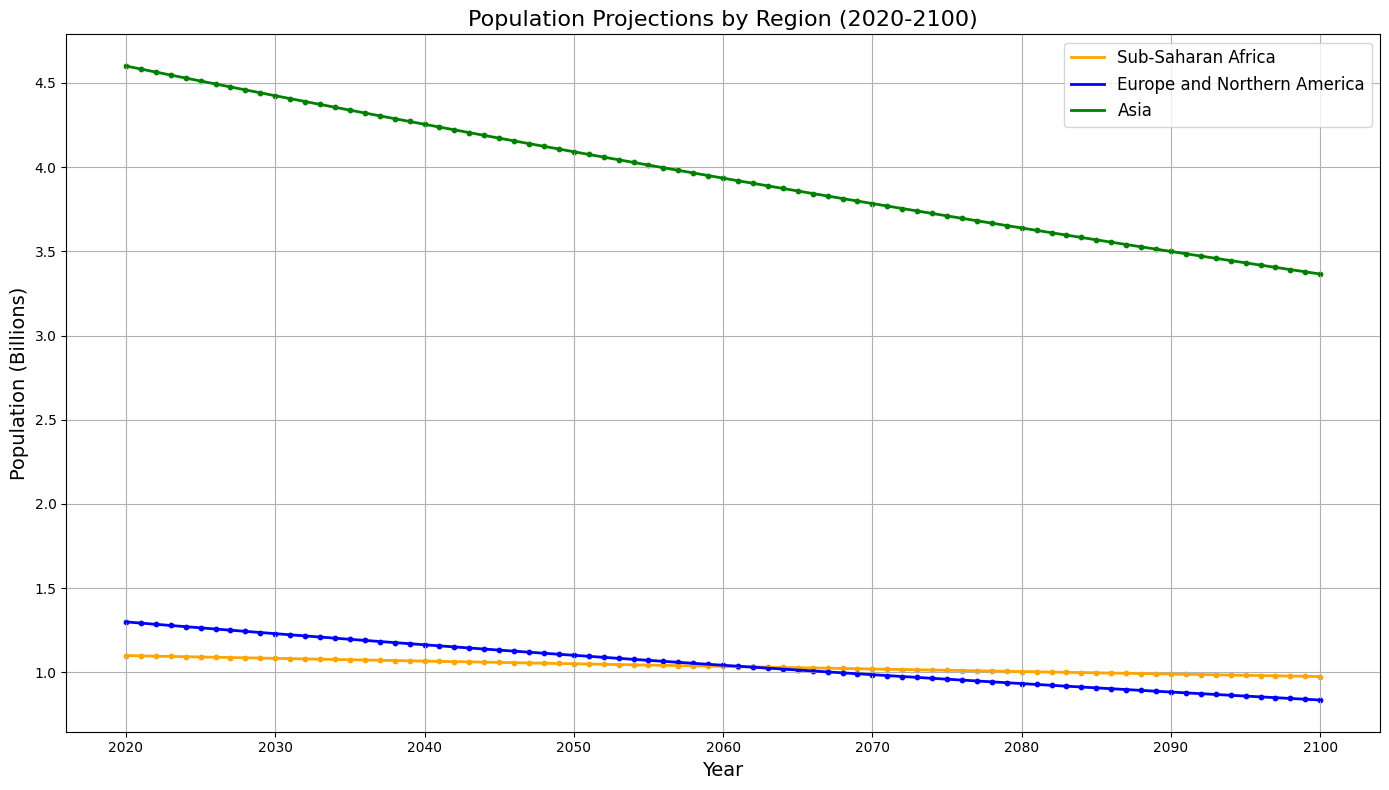

In [6]:
plt.figure(figsize=(14, 8))

colors = {
    'Sub-Saharan Africa': 'orange',
    'Europe and Northern America': 'blue',
    'Asia': 'green'
}

for region in regions.keys():
    subset = all_projections[all_projections['Region'] == region]
    plt.plot(subset['Year'] + 2020, subset['Population'] / 1e9, label=region, color=colors[region], linewidth=2)
    plt.scatter(subset['Year'] + 2020, subset['Population'] / 1e9, color=colors[region], s=10)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Population (Billions)', fontsize=14)
plt.title('Population Projections by Region (2020-2100)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


### Experiment 2: Impact of Increased Fertility Rates
Objective: Explore how changes in fertility rates affect population growth.

- Modify the fertility_rate for Sub-Saharan Africa from 4.5 to 5.5.
- Rerun the projection and update the plot.
- Observe the changes in the population trajectory.

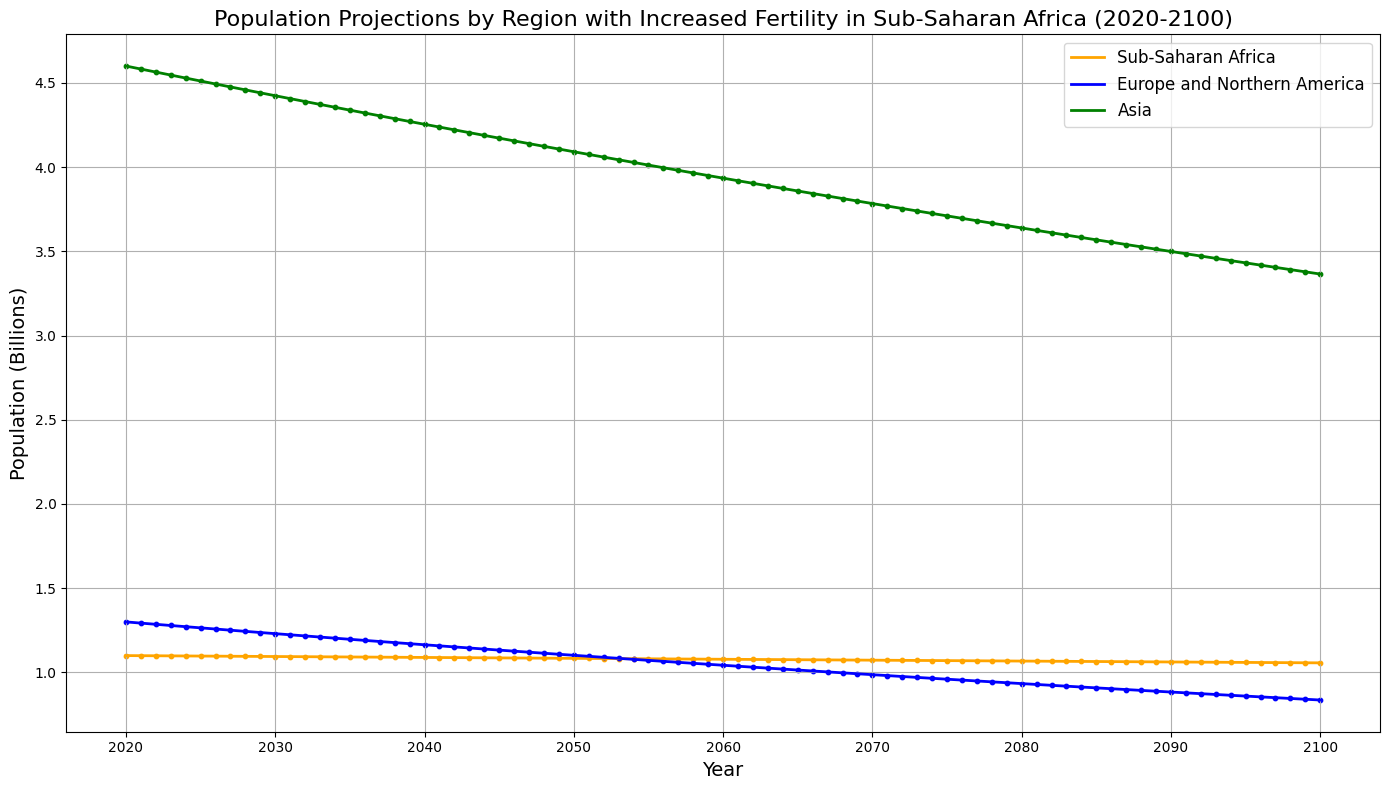

In [7]:
# Update fertility rate for Sub-Saharan Africa
regions['Sub-Saharan Africa']['fertility_rate'] = 5.5

# Re-run the projections
all_projections = pd.DataFrame()

for region, params in regions.items():
    df = population_projection(
        initial_population=params['initial_population'],
        fertility_rate=params['fertility_rate'],
        mortality_rate=params['mortality_rate'],
        migration_rate=params['migration_rate'],
        years=projection_years
    )
    df['Region'] = region
    all_projections = pd.concat([all_projections, df], ignore_index=True)

# Plot the updated projections
plt.figure(figsize=(14, 8))

colors = {
    'Sub-Saharan Africa': 'orange',
    'Europe and Northern America': 'blue',
    'Asia': 'green'
}

for region in regions.keys():
    subset = all_projections[all_projections['Region'] == region]
    plt.plot(subset['Year'] + 2020, subset['Population'] / 1e9, label=region, color=colors[region], linewidth=2)
    plt.scatter(subset['Year'] + 2020, subset['Population'] / 1e9, color=colors[region], s=10)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Population (Billions)', fontsize=14)
plt.title('Population Projections by Region with Increased Fertility in Sub-Saharan Africa (2020-2100)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


### Experiment 3: Impact of Decreased Mortality Rates
Objective: Investigate how reductions in mortality rates influence population growth and aging.

- Decrease the mortality_rate for Europe and Northern America from 10 to 8.
- Rerun the projection and update the plot.
- Analyze the implications on population size and aging.

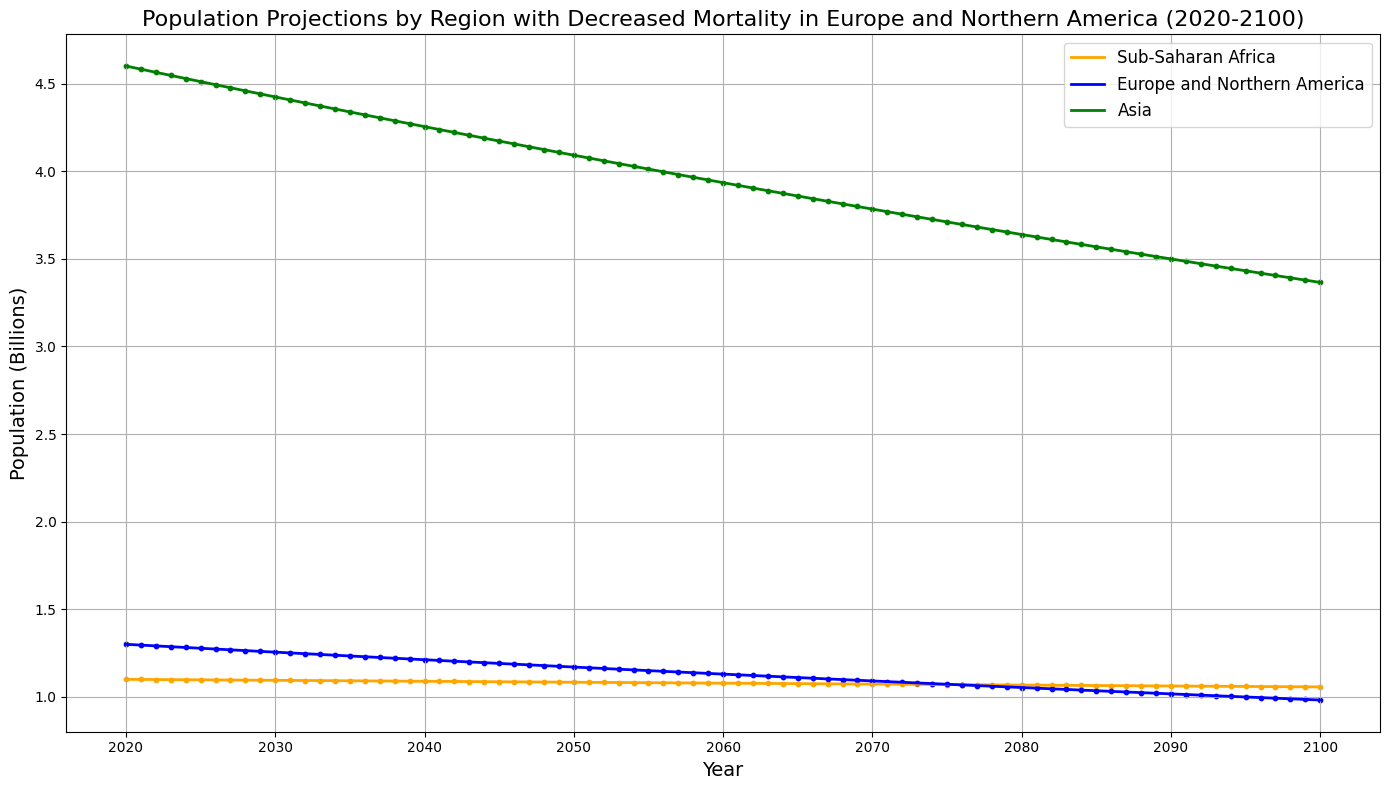

In [8]:
# Update mortality rate for Europe and Northern America
regions['Europe and Northern America']['mortality_rate'] = 8

# Re-run the projections
all_projections = pd.DataFrame()

for region, params in regions.items():
    df = population_projection(
        initial_population=params['initial_population'],
        fertility_rate=params['fertility_rate'],
        mortality_rate=params['mortality_rate'],
        migration_rate=params['migration_rate'],
        years=projection_years
    )
    df['Region'] = region
    all_projections = pd.concat([all_projections, df], ignore_index=True)

# Plot the updated projections
plt.figure(figsize=(14, 8))

for region in regions.keys():
    subset = all_projections[all_projections['Region'] == region]
    plt.plot(subset['Year'] + 2020, subset['Population'] / 1e9, label=region, color=colors[region], linewidth=2)
    plt.scatter(subset['Year'] + 2020, subset['Population'] / 1e9, color=colors[region], s=10)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Population (Billions)', fontsize=14)
plt.title('Population Projections by Region with Decreased Mortality in Europe and Northern America (2020-2100)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Experiment 4: Impact of Increased Migration Rates
Objective: Examine how higher migration rates affect population growth in Europe and Northern America.

- Increase the migration_rate for Europe and Northern America from 3 to 5.
- Rerun the projection and update the plot.
- Observe the changes in population size due to migration.

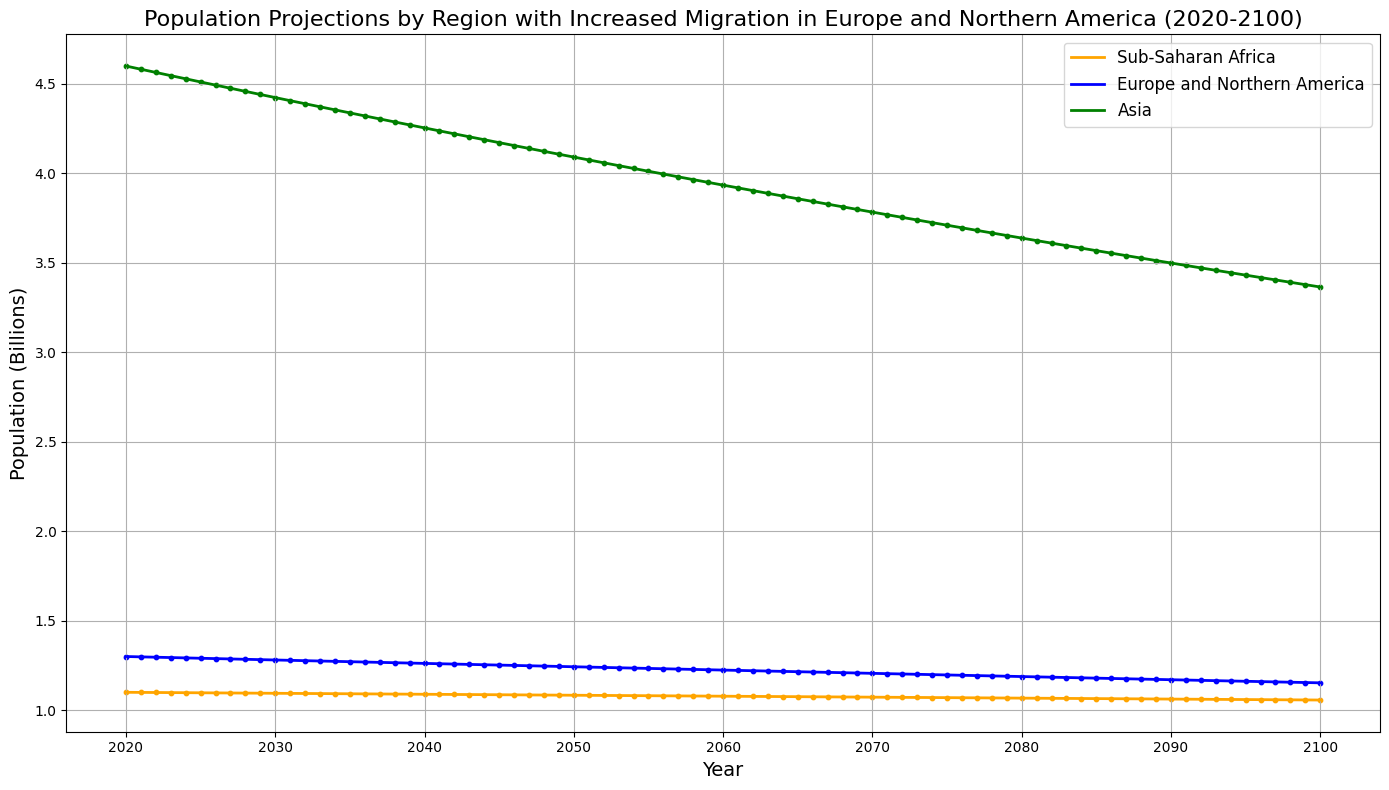

In [9]:
# Update migration rate for Europe and Northern America
regions['Europe and Northern America']['migration_rate'] = 5

# Re-run the projections
all_projections = pd.DataFrame()

for region, params in regions.items():
    df = population_projection(
        initial_population=params['initial_population'],
        fertility_rate=params['fertility_rate'],
        mortality_rate=params['mortality_rate'],
        migration_rate=params['migration_rate'],
        years=projection_years
    )
    df['Region'] = region
    all_projections = pd.concat([all_projections, df], ignore_index=True)

# Plot the updated projections
plt.figure(figsize=(14, 8))

for region in regions.keys():
    subset = all_projections[all_projections['Region'] == region]
    plt.plot(subset['Year'] + 2020, subset['Population'] / 1e9, label=region, color=colors[region], linewidth=2)
    plt.scatter(subset['Year'] + 2020, subset['Population'] / 1e9, color=colors[region], s=10)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Population (Billions)', fontsize=14)
plt.title('Population Projections by Region with Increased Migration in Europe and Northern America (2020-2100)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. **Observations & Exercises**

#### Implications of Population Momentum
Population momentum ensures that even with declining fertility rates, the population continues to grow for several decades. This is due to a relatively young population structure, where a large base of young individuals will enter their reproductive years, sustaining population growth.

#### Aging Populations
Regions with declining fertility and increasing life expectancy face challenges related to aging populations, such as increased healthcare costs, pension burdens, and labor shortages. Policies aimed at supporting the elderly and maintaining a stable workforce are essential.

#### Migration's Role
Migration can significantly influence population trends, particularly in regions experiencing low fertility rates. High net migration can sustain or even increase population sizes, mitigating the effects of aging and labor shortages.

#### Urbanization Trends
Urbanization impacts economic development, infrastructure needs, and environmental sustainability. Rapid urban growth requires effective planning to ensure that cities can accommodate increasing populations without compromising quality of life or environmental standards.

### **Practical Exercises**
**Exercise 1**: Sensitivity Analysis on Fertility Rates

Objective: Understand how sensitive population projections are to changes in fertility rates.

- Choose one region (e.g., Sub-Saharan Africa).
- Create projections with fertility rates varying by ±1 birth per 1,000 population per year (e.g., 4.0, 4.5, 5.0).
- Plot all three scenarios on the same graph.
- Analyze how changes in fertility rates affect the population trajectory.

**Exercise 2**: Urbanization Impact on Population Distribution

Objective: Analyze how urbanization affects population distribution within regions.

- For each region, define an urbanization rate (percentage of population moving to urban areas per year).
- Project the urban and rural populations separately.
- Plot urban vs. rural population over time.

**Exercise 3**: Scenario Analysis with Policy Changes
Objective: Assess how hypothetical policy changes (e.g., migration restrictions, fertility incentives) impact population growth.

- Define a policy scenario, such as reducing migration rates in Europe and Northern America to 1 per 1,000 population per year.
- Modify the migration rate accordingly.
- Rerun the projection and plot the results.
- Compare with the baseline to understand the policy's impact.

**Exercise 4**: Global projections given regional changes

Objective: Explore what the global projections look like for a given scenario (e.g. reduced US and EU migration rates and decreased mortality in Sub-Saharan Africa)

- Define a scenario with tweaked regional fertility rates / migration rates, mortality rates, etc.
- Plot the scenario using the separated regional projection lines
- Plot the scenario using a combined global projection line

In [10]:
# Write your code here


## 7. Conclusion
Summary:

In this laboratory, you explored major trends in global population growth as outlined in the paper by Gu, Andreev, and Dupre. By implementing a simplified population projection model, you gained insights into how fertility, mortality, migration, and population momentum influence future demographic landscapes. The simulation provided a practical understanding of the theoretical concepts and highlighted the significant regional differences in population dynamics.
______________

Resources for other scientific-based model explorations:

https://pmc.ncbi.nlm.nih.gov/

https://arxiv.org/search/

https://www.nature.com/search/advanced


Could generally start an exploration by googling the name of the topic you are interested in, then prefixing it with 'paper'. E.g. 'population growth different countries paper' will lead you to papers about population growth separated per countries/regions.


## 8. Tips for Extracting Key Information from Research Papers

When approaching a scientific paper — especially with the goal in mind of modeling a system around it — it's crucial to read efficiently and critically. Here are some tips to help you extract the key information needed for your modeling work:

1. **Start with the Abstract:**  
   The abstract provides a high-level summary of the paper’s objectives, methods, and key findings. After reading it, you should understand the main contributions without diving into details.

2. **Focus on the Introduction and Conclusion:**  
   The introduction sets the context, explains why the research matters, and often introduces the main variables or parameters under study. The conclusion reiterates the main takeaways, policy implications, and potential avenues for future research.

3. **Identify Key Parameters and Assumptions:**  
   Skim through the methodology and results sections to pick out critical parameters, such as fertility, mortality, migration rates, or other variables relevant to your model. Look for tables or summary points where these parameters are explicitly stated.

4. **Don’t Get Lost in Complex Mathematics:**  
   Unless you’re required to replicate the mathematical derivations, you can often skip the most complex equations. Instead, look for plain-language explanations or summaries of what those equations represent. Try to understand the logic rather than every mathematical detail.

5. **Use Figures and Tables:**  
   Graphs, charts, and tables can quickly convey trends, comparisons, and key results. Focus on these visual elements to confirm the insights you’ve gleaned from the text and to pinpoint numerical values you can plug into your model.

6. **Read for Relationships and Trends, Not Just Numbers:**  
   While exact parameter values are important for modeling, also pay attention to how these values relate to each other. For example, a declining fertility rate coupled with increasing life expectancy suggests a future increase in the proportion of older adults. These relationships guide how you structure and interpret your model.

7. **Note Limitations and Assumptions:**  
   Papers often mention what’s uncertain, what’s assumed, and what’s simplified. Understanding these caveats is crucial so you know the boundaries of your model’s applicability and where you might need to adjust parameters or run sensitivity analyses.
